In [1]:
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score,mean_squared_error

In [2]:
insurance=pd.read_csv("insurance.csv")


X=insurance.drop(columns=["charges"])
y=insurance["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype="int")

X["smoker"]=X["smoker"].map({"yes":1,"no":0})
X["sex"]=X["sex"].map({"female":1,"male":0})

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


mean square error for alpha0.01 is  33912212.30392797
mean square error for alpha0.1 is  40372365.57421895
mean square error for alpha2 is  106474117.5126379
mean square error for alpha3 is  113559105.70589207
mean square error for alpha4 is  117533550.9790933
mean square error for alpha5 is  120083624.96314071
mean square error for alpha10 is  125673504.21531565
mean square error for alpha20 is  128970781.66507268
mean square error for alpha30 is  130373432.10442156
mean square error for alpha40 is  131281142.1851822
mean square error for alpha50 is  131980823.66494916
mean square error for alpha100 is  134387656.60503694


<Axes: >

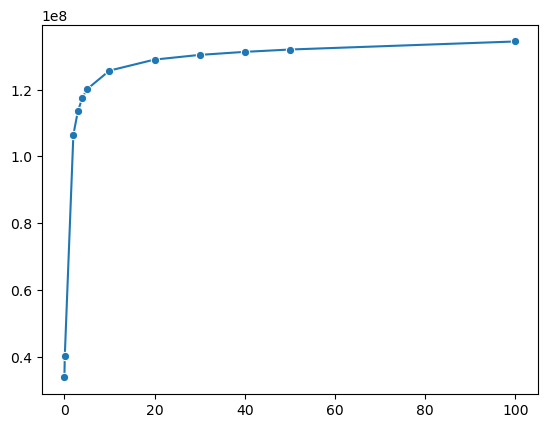

In [3]:
alphas=[0.01,0.1,2,3,4,5,10,20,30,40,50,100]
mses=[]
for a in alphas:
        
    elastic_model=ElasticNet(alpha=a)
    elastic_model.fit(X_train,y_train)

    y_pred=elastic_model.predict(X_test)

    mse_value=mean_squared_error(y_test,y_pred)
    print(f"mean square error for alpha{a} is ",mse_value)
    mses.append(mse_value)

sns.lineplot(x=alphas,y=mses,marker="o")

In [4]:
from sklearn.linear_model import ElasticNetCV
elasticnet_cv_model = ElasticNetCV(
    alphas=[0.001,0.01,0.1,1,2,5,10,20,30,40,50,100],
    cv=5
)

elasticnet_cv_model.fit(X_train,y_train)

print("Best Alpha:",elasticnet_cv_model.alpha_)

y_pred=elasticnet_cv_model.predict(X_test)

r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
print("mse=",mse)
print("r2=",r2)

Best Alpha: 0.001
mse= 33622010.331672184
r2= 0.7834313362267067
